In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from cycles import Planting, FixedFertilization, Tillage
from cycles import generate_operation_file
from cycles import plot_operations, plot_satellite_map
from cycles.weather import find_grids
from cycles.ssurgo import Ssurgo
from pathlib import Path
from config import PATH, STUDY_YEARS, FIELD_BOUNDARY_SHAPEFILE, FIELD_BOUNDING, GSSURGO_DATA_PATH
from config import TREATMENTS
from config import Dataset

# Soil file and weather file

/storage/work/yzs123/.conda/envs/my_root/lib/python3.14/site-packages/pyogrio/raw.py:198: RuntimeWarning: organizePolygons() received a polygon with more than 100 parts. The processing may be really slow.  You can skip the processing by setting METHOD=SKIP, or only make it analyze counter-clock wise parts by setting METHOD=ONLY_CCW if you can assume that the outline of holes is counter-clock wise defined
  return ogr_read(


              muname                                           geometry  \
0      Nicollet loam  MULTIPOLYGON (((185234.4 2104194.4, 185232.8 2...   
1  Webster clay loam  MULTIPOLYGON (((185386.4 2104183.4, 185389.3 2...   

     mukey musym  slopegradwta hydgrpdcd          area  
0  2834849   L55           2.1       B/D  20244.010978  
1  2835012  L107           1.0       C/D  19914.484689  
NLDAS weather files:
site                         input_coordinate          weather_file
None (41.920912945884425, -93.74814722081048) NLDAS_41.938Nx93.688W



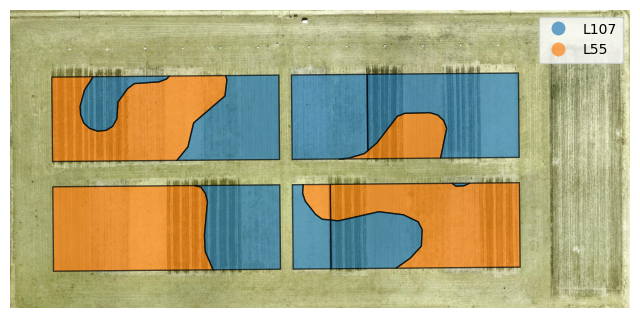

In [2]:
boundary = gpd.read_file(FIELD_BOUNDARY_SHAPEFILE)
centroid = boundary.to_crs('+proj=cea').centroid.to_crs('epsg:4326')

ssurgo = Ssurgo(GSSURGO_DATA_PATH, 'IA', boundary=boundary)
print(ssurgo.grouped_mapunits)

fig = plt.figure(figsize=(8, 6))
ax, crs = plot_satellite_map(fig, FIELD_BOUNDING)
ssurgo.grouped_mapunits.to_crs(crs).plot(ax=ax, alpha=0.67, edgecolor='k')
ssurgo.generate_soil_file(Path('./input') / 'COBS.soil')

weather_file = find_grids('NLDAS', locations=[(centroid.y[0], centroid.x[0])])

In [3]:
for index, row in ssurgo.grouped_mapunits.iterrows():
    ssurgo.generate_soil_file(Path('./input') / f'{row['musym']}.soil', mukey=row['mukey'])

# Operation files

In [4]:
def read_and_filter_csv(dataset: Dataset, treatment: str) -> pd.DataFrame:
    if treatment not in TREATMENTS:
        raise ValueError(f"Invalid treatment: {treatment}. Must be one of {TREATMENTS}.")

    df = pd.read_csv(dataset.csv_path)
    df = df[df.apply(TREATMENTS[treatment].treatment_filter, axis=1)]
    df = df[df['blocks'].str.contains('1')]
    df['study_year'] = df['study_year'].astype(int)
    df[dataset.date_column] = pd.to_datetime(df[dataset.date_column])
    df = df.sort_values(dataset.date_column)

    return df


def get_crop_rm(crop: str, maturity_value: float) -> str:
    if crop.lower() == 'corn' and pd.notna(maturity_value):
        return f'{crop.title()}RM.{round(maturity_value / 5.0) * 5}'
    elif crop.lower() == 'soybean':
        return f'{crop.title()}MG.{round(maturity_value)}' if pd.notna(maturity_value) else f'{crop.title()}MG.3'
    else:
        return crop.title()


def load_planting_activities(treatment: str) -> list[Planting]:
    df = read_and_filter_csv(Dataset.PLANTING_ACTIVITIES, treatment)

    plantings = [
        Planting(
            year=row['study_year'] - STUDY_YEARS[0] + 1,
            doy=row['planting_date'].dayofyear,
            crop=get_crop_rm(row['crop'].strip().split('_')[0], row['maturity_value']),
            **TREATMENTS[treatment].planting_management[row['crop'].split('_')[0]],
        )
        for _, row in df.iterrows()
    ]

    return plantings


def load_fertilization_activities(treatment: str) -> list[FixedFertilization]:
    df = read_and_filter_csv(Dataset.CHEMICAL_INPUTS, treatment)
    df['reference_chemical'] = df['reference_chemical'].map(lambda x: str(x).strip())
    df = df[df['reference_chemical'] == 'nitrogen (N)']

    fertilizations = [
        FixedFertilization(
            year=row['study_year'] - STUDY_YEARS[0] + 1,
            doy=row['application_date'].dayofyear,
            mass=row['application_rate_of_reference_chemical_value'] * 1.12,    # convert from lb/ac to kg/ha
            source='nitrogen',
            method=str(row['application_mode']).title(),
            depth=0.075 if row['application_mode'] == 'injection' else 0.0,
        )
        for _, row in df.iterrows()
    ]

    return fertilizations


def load_harvest_activities(treatment: str) -> list[Tillage]:
    df = read_and_filter_csv(Dataset.HARVEST_ACTIVITIES, treatment)
    df = df[df.apply(TREATMENTS[treatment].harvest_filter, axis=1)]

    harvests = [
        Tillage(
            year=row['study_year'] - STUDY_YEARS[0] + 1,
            doy=row['activity_date'].dayofyear,
            tool=TREATMENTS[treatment].harvest_management[row['crop'].split('_')[0]],
            crop_name=row['crop'].title(),
        )
        for _, row in df.iterrows()
    ]

    return harvests


def clean_up_operations(operations: list) -> list:
    operations.sort(key=lambda op: (op.year, op.doy))
    for ind, op in enumerate(operations):
        if isinstance(op, Tillage) and ('harvest' in op.tool.lower() or 'kill' in op.tool.lower()):
            planting = next((op for op in reversed(operations[:ind + 1]) if isinstance(op, Planting)), None)
            if planting.crop.lower().startswith(op.crop_name.lower().split('_')[0]):
                op.crop_name = planting.crop

    return operations

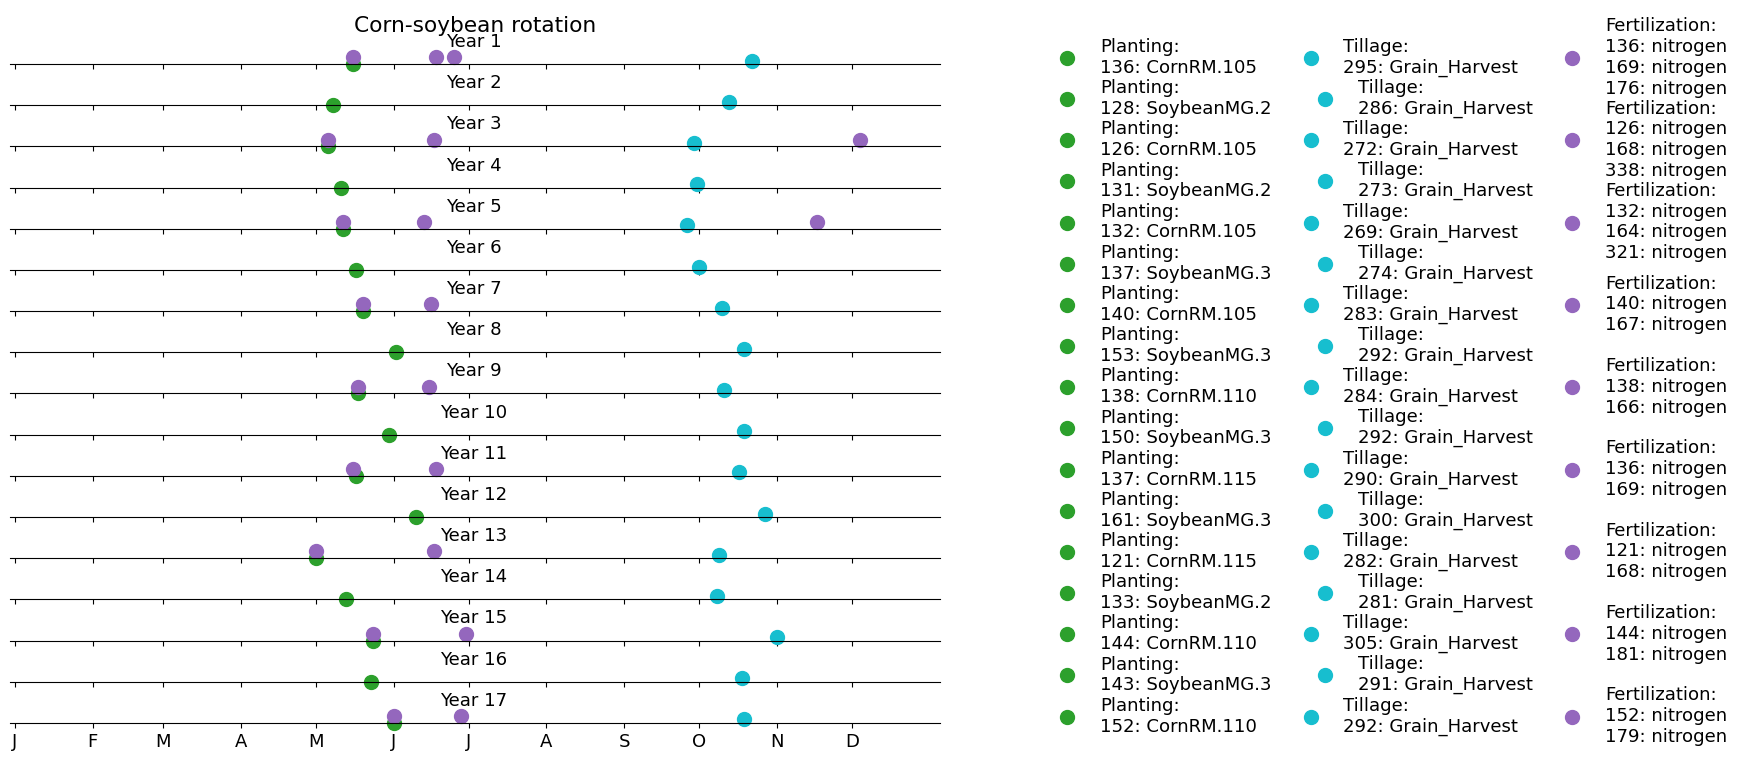

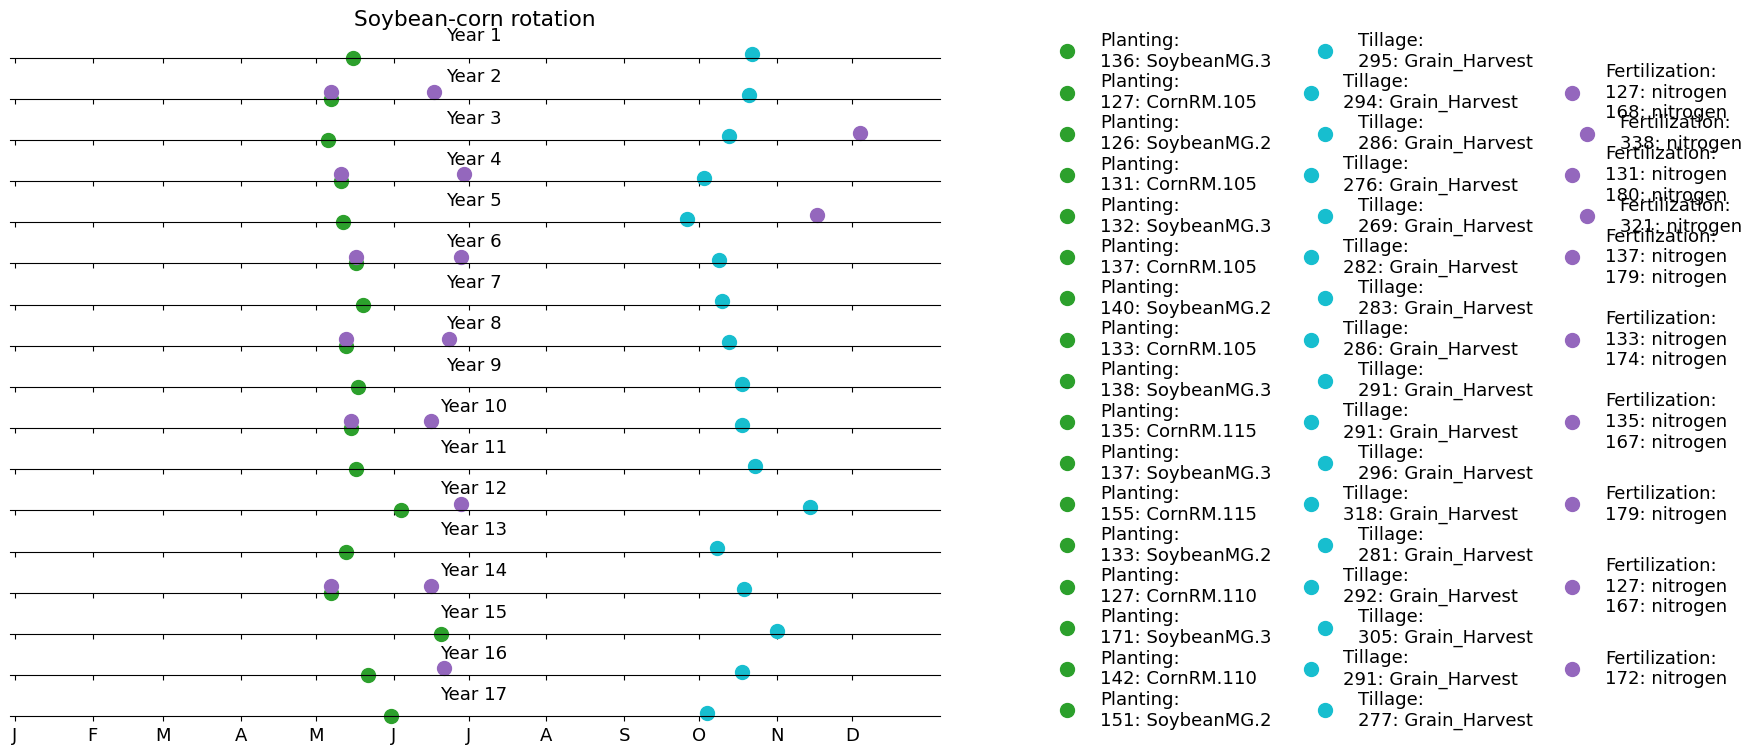

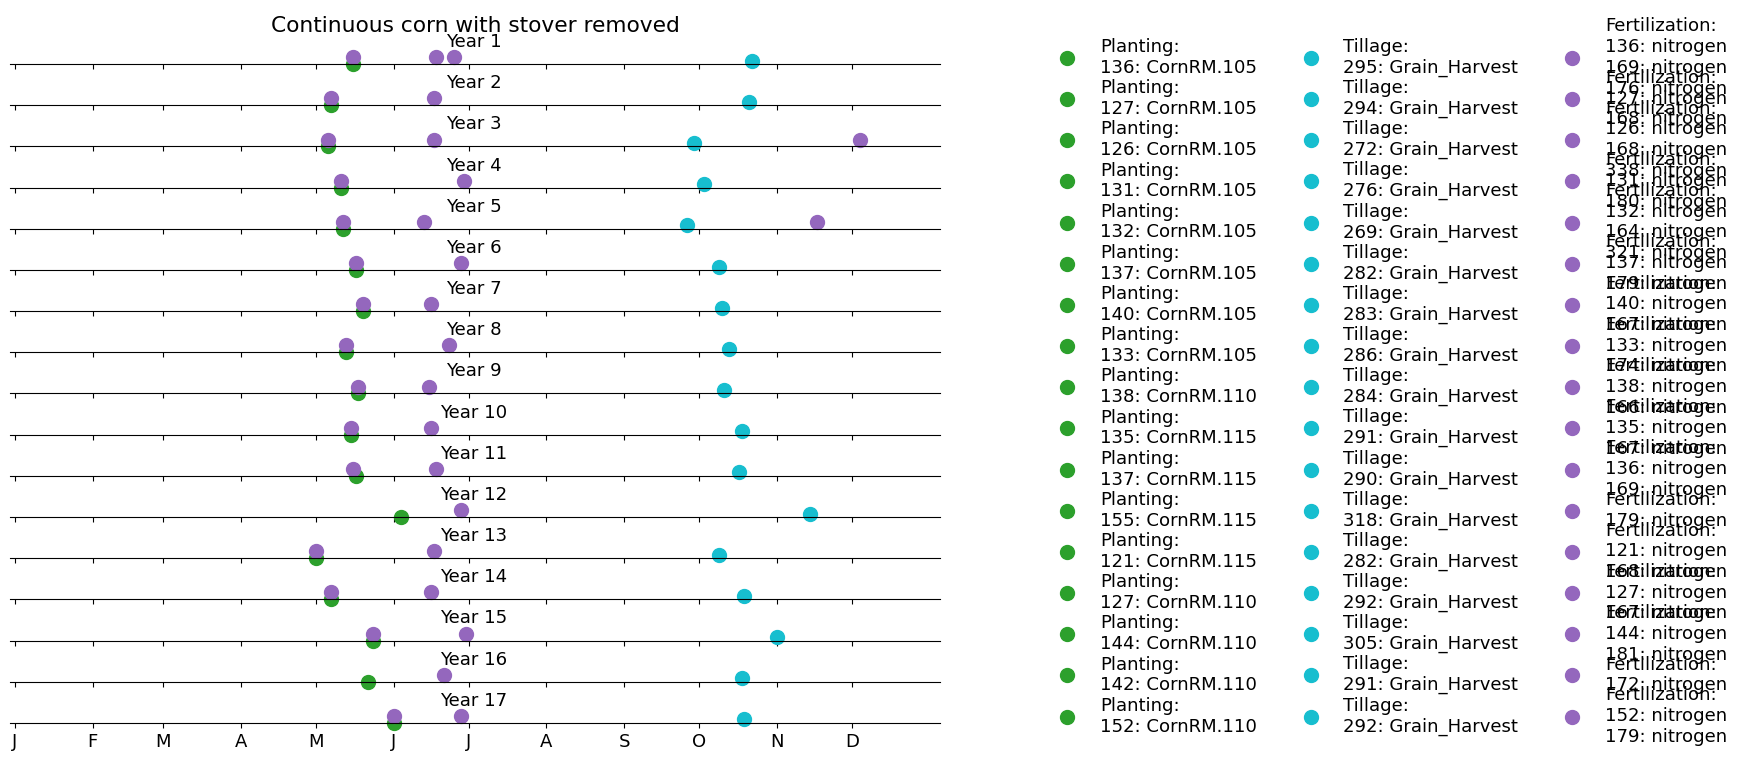

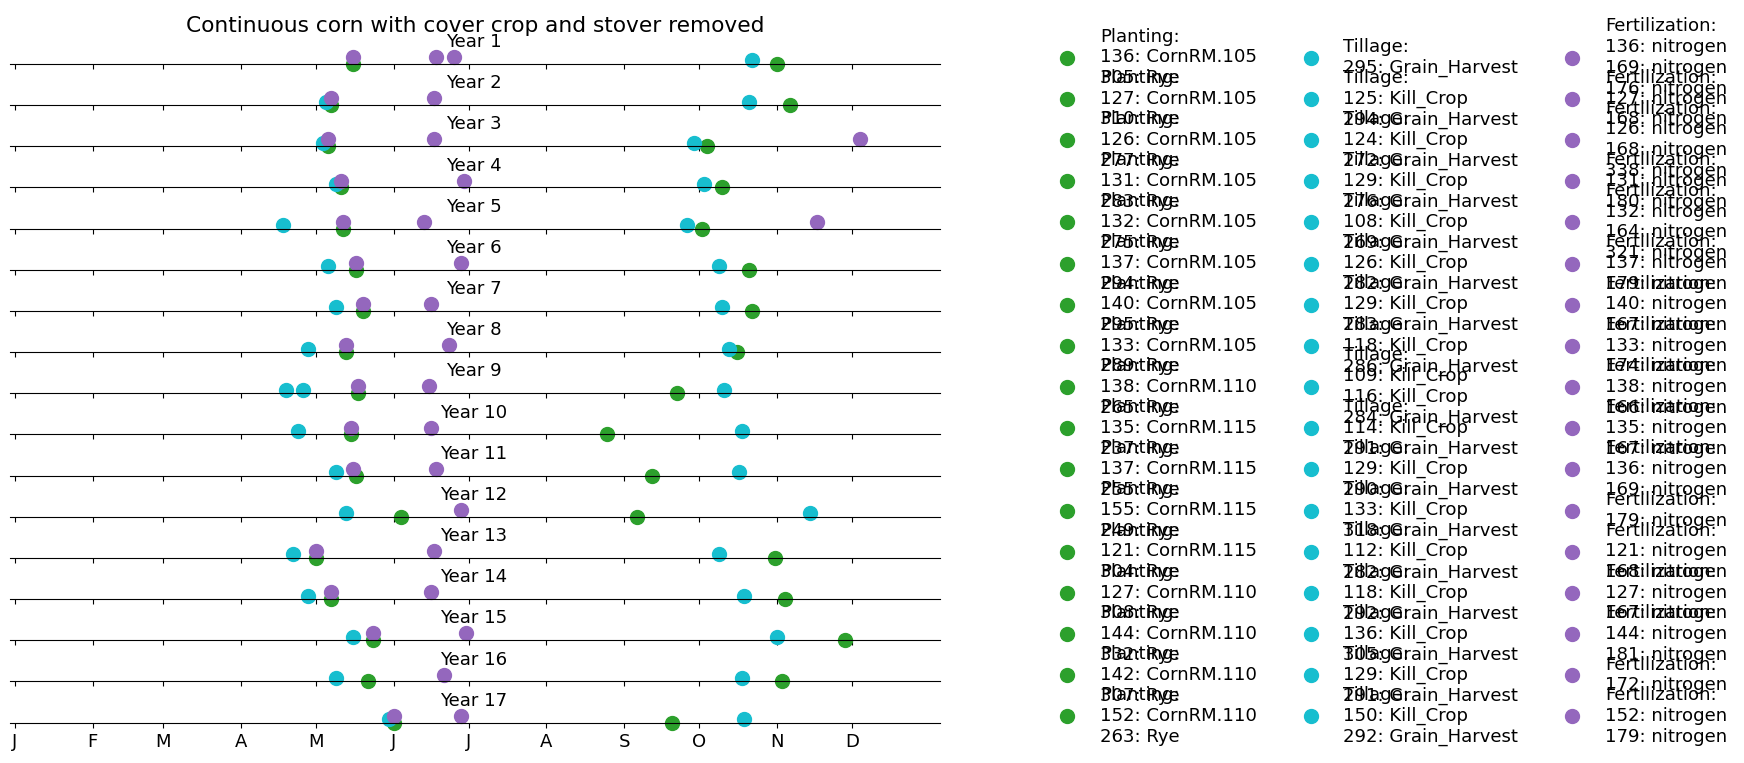

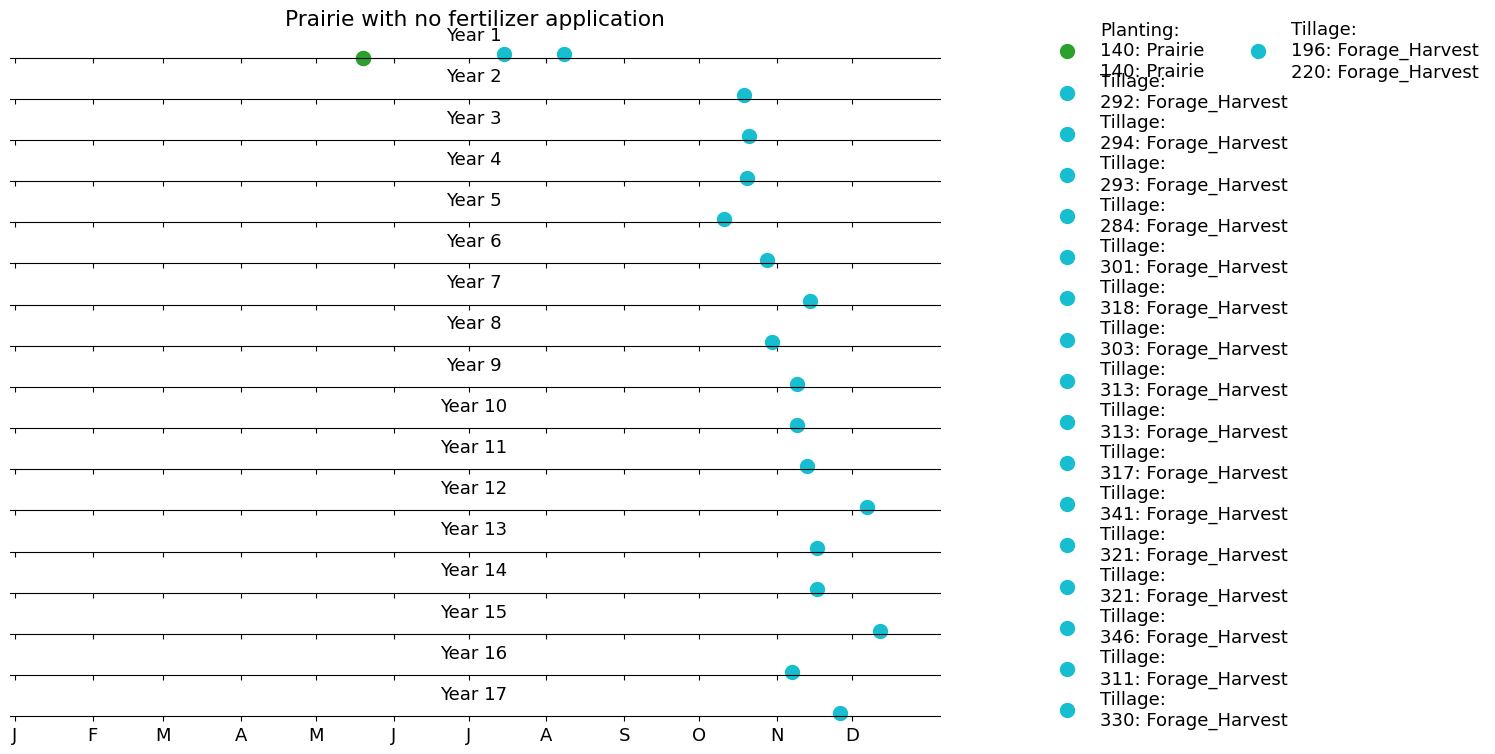

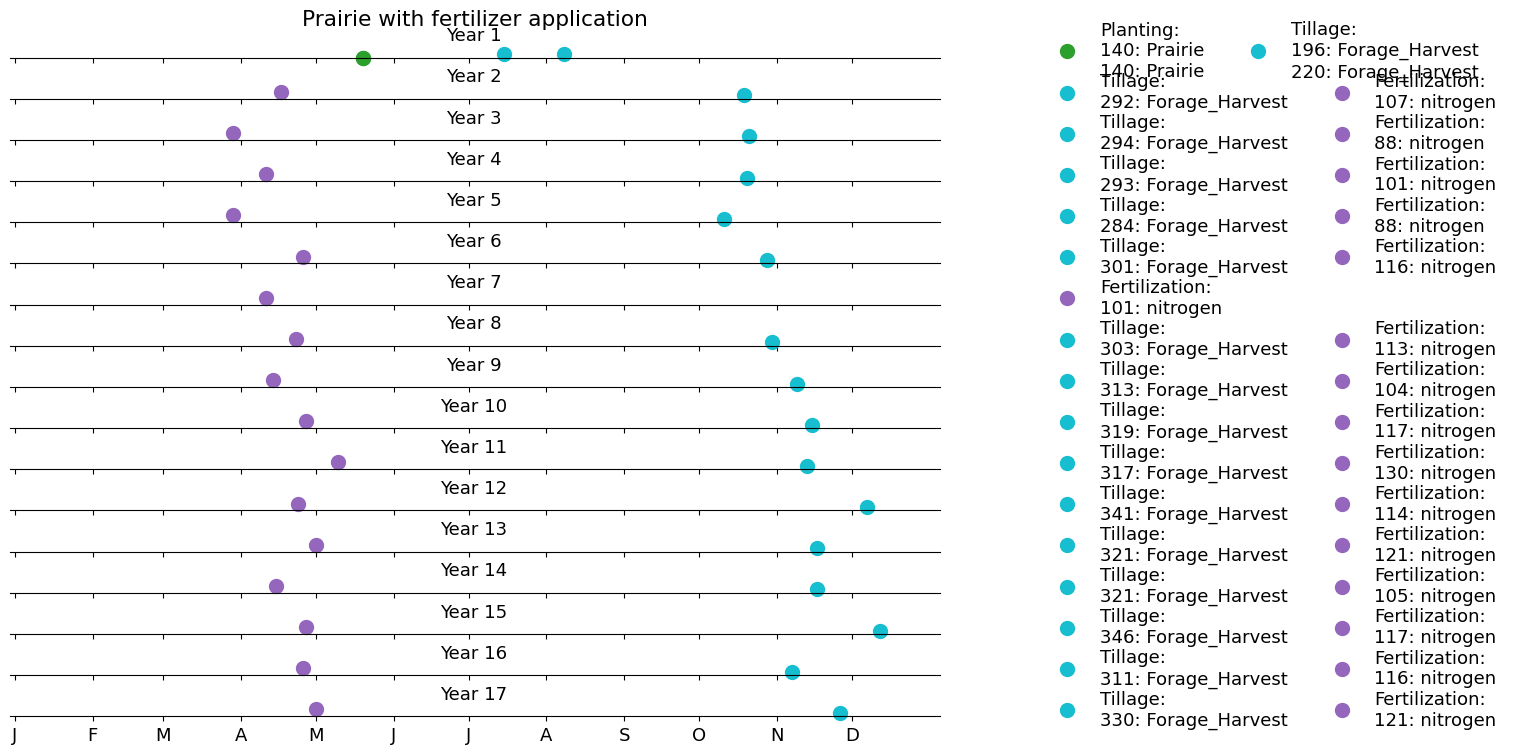

In [5]:
for treatment in TREATMENTS:
    operations = []
    operations += load_planting_activities(treatment)
    operations += load_fertilization_activities(treatment)
    operations += load_harvest_activities(treatment)

    operations = clean_up_operations(operations)

    years = STUDY_YEARS[1] - STUDY_YEARS[0] + 1
    fig, axs = plt.subplots(years, 1, figsize=(12, 9), sharex=True)
    plot_operations(operations, STUDY_YEARS[1] - STUDY_YEARS[0] + 1, axs=axs, fontsize=13)
    axs[0].set_title(TREATMENTS[treatment].description)

    generate_operation_file(PATH / 'input' / f'COBS_{treatment}.operation', operations, desc='# ' + TREATMENTS[treatment].description + '\n')